# Download the Full data from kaggle

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pinxau1000/radioml2018")

print("Path to dataset files:", path)

100%|██████████| 18.0G/18.0G [03:37<00:00, 88.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2


In [5]:
import os
os.listdir('/root/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2/')

['datasets.desktop',
 'classes.txt',
 'classes-fixed.json',
 'GOLD_XYZ_OSC.0001_1024.hdf5',
 'LICENSE.TXT',
 'classes-fixed.txt']

# Process and Reduce the size

In [6]:
dataset_path = "/root/.cache/kagglehub/datasets/pinxau1000/radioml2018/versions/2/GOLD_XYZ_OSC.0001_1024.hdf5"

In [8]:
import numpy as np
import h5py

MODS = 24
SNRs = 26
SAMPLES = 4096

# SNR value for bin index i: -20 + 2*i  (bins 0..25 -> -20dB..30dB)
def snr_bin_to_db(i):
    return -20 + 2 * i

# # --- choose what to keep, matching CONFIG in your notebook ---
# MOD_LIST = [  # official 24-class order (must match get_modulation_list())
#     "OOK", "4ASK", "8ASK", "BPSK", "QPSK", "8PSK", "16PSK", "32PSK",
#     "16APSK", "32APSK", "64APSK", "128APSK", "16QAM", "32QAM", "64QAM",
#     "128QAM", "256QAM", "AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC", "AM-DSB-SC",
#     "FM", "GMSK", "OQPSK",
# ]


MODS_TO_KEEP = ["BPSK", "QPSK", "8PSK", "16QAM", "64QAM", "GMSK", "AM-DSB-WC", "AM-DSB-SC"]

SNRS_TO_KEEP_DB = [-10, -6, -2, 0, 2, 6, 10, 14, 18]
SAMPLES_PER_MOD_SNR = 500  # >= your n_per_mod_snr=400, gives headroom for random draw

def getSignalIndex(mod, snr_bin, signal):
    return (SAMPLES * SNRs * mod) + (SAMPLES * snr_bin) + signal

mod_indices = [MOD_LIST.index(m) for m in MODS_TO_KEEP]
snr_bins = [ (snr_db + 20)//2 for snr_db in SNRS_TO_KEEP_DB ]

n_total = len(mod_indices) * len(snr_bins) * SAMPLES_PER_MOD_SNR
n_classes = len(MOD_LIST)

with h5py.File(dataset_path, "r") as f:
    x = f["X"]

    with h5py.File("DEEPSIG_2018_reduced.hdf5", "w") as f2:
        X2 = f2.create_dataset("X", (n_total, 1024, 2), dtype="float32")
        Y2 = f2.create_dataset("Y", (n_total, n_classes), dtype="int8")
        Z2 = f2.create_dataset("Z", (n_total, 1), dtype="int64")

        idx = 0
        for mod in mod_indices:
            for snr_bin in snr_bins:
                snr_db = snr_bin_to_db(snr_bin)
                for s in range(SAMPLES_PER_MOD_SNR):
                    i = getSignalIndex(mod, snr_bin, s)
                    X2[idx] = x[i]                     # full I+Q, unlike original script
                    y_onehot = np.zeros(n_classes, dtype="int8")
                    y_onehot[mod] = 1
                    Y2[idx] = y_onehot
                    Z2[idx, 0] = snr_db
                    idx += 1
                print(f"mod={MOD_LIST[mod]} snr={snr_db}dB done")

print("Reduced dataset created:", n_total, "rows")

mod=BPSK snr=-10dB done
mod=BPSK snr=-6dB done
mod=BPSK snr=-2dB done
mod=BPSK snr=0dB done
mod=BPSK snr=2dB done
mod=BPSK snr=6dB done
mod=BPSK snr=10dB done
mod=BPSK snr=14dB done
mod=BPSK snr=18dB done
mod=QPSK snr=-10dB done
mod=QPSK snr=-6dB done
mod=QPSK snr=-2dB done
mod=QPSK snr=0dB done
mod=QPSK snr=2dB done
mod=QPSK snr=6dB done
mod=QPSK snr=10dB done
mod=QPSK snr=14dB done
mod=QPSK snr=18dB done
mod=8PSK snr=-10dB done
mod=8PSK snr=-6dB done
mod=8PSK snr=-2dB done
mod=8PSK snr=0dB done
mod=8PSK snr=2dB done
mod=8PSK snr=6dB done
mod=8PSK snr=10dB done
mod=8PSK snr=14dB done
mod=8PSK snr=18dB done
mod=16QAM snr=-10dB done
mod=16QAM snr=-6dB done
mod=16QAM snr=-2dB done
mod=16QAM snr=0dB done
mod=16QAM snr=2dB done
mod=16QAM snr=6dB done
mod=16QAM snr=10dB done
mod=16QAM snr=14dB done
mod=16QAM snr=18dB done
mod=64QAM snr=-10dB done
mod=64QAM snr=-6dB done
mod=64QAM snr=-2dB done
mod=64QAM snr=0dB done
mod=64QAM snr=2dB done
mod=64QAM snr=6dB done
mod=64QAM snr=10dB done
mod=6

# Copy the created dataset to your google drive

In [9]:
from google.colab import drive
drive.mount('/content/mydrive')

Mounted at /content/mydrive


In [10]:
!mkdir /content/mydrive/MyDrive/radioml2018
%cd '/content/mydrive/MyDrive/radioml2018'

/content/mydrive/MyDrive/radioml2018


In [11]:
!mv /content/DEEPSIG_2018_reduced.hdf5 .

# Data Exploratory

File size: 296,066,048 bytes  (282.35 MB / 0.276 GB)

X shape: (36000, 1024, 2) float32
Y shape: (36000, 24) int8
Z shape: (36000, 1) int64
Modulations present: ['BPSK', 'QPSK', '8PSK', '16QAM', '64QAM', 'AM-DSB-WC', 'AM-DSB-SC', 'GMSK']
SNRs present (dB): [-10, -6, -2, 0, 2, 6, 10, 14, 18]
Total samples: 36000



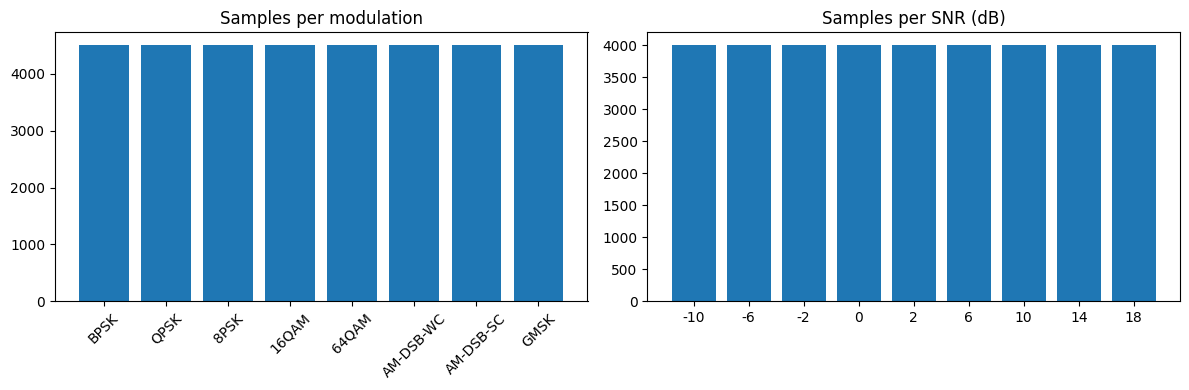

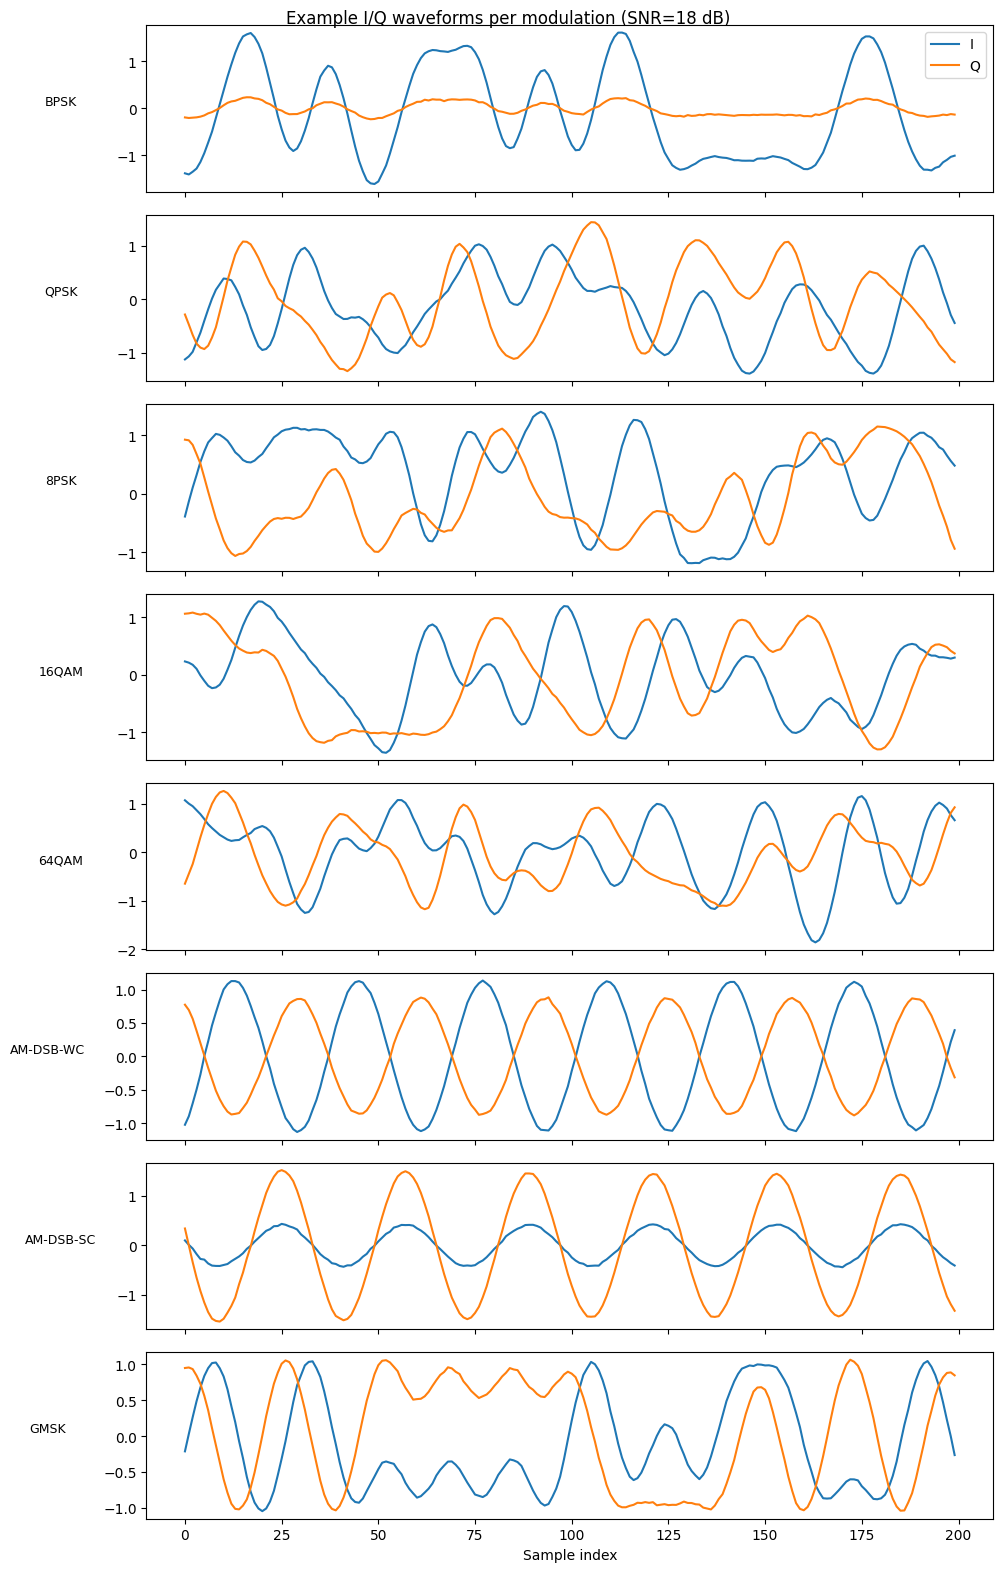

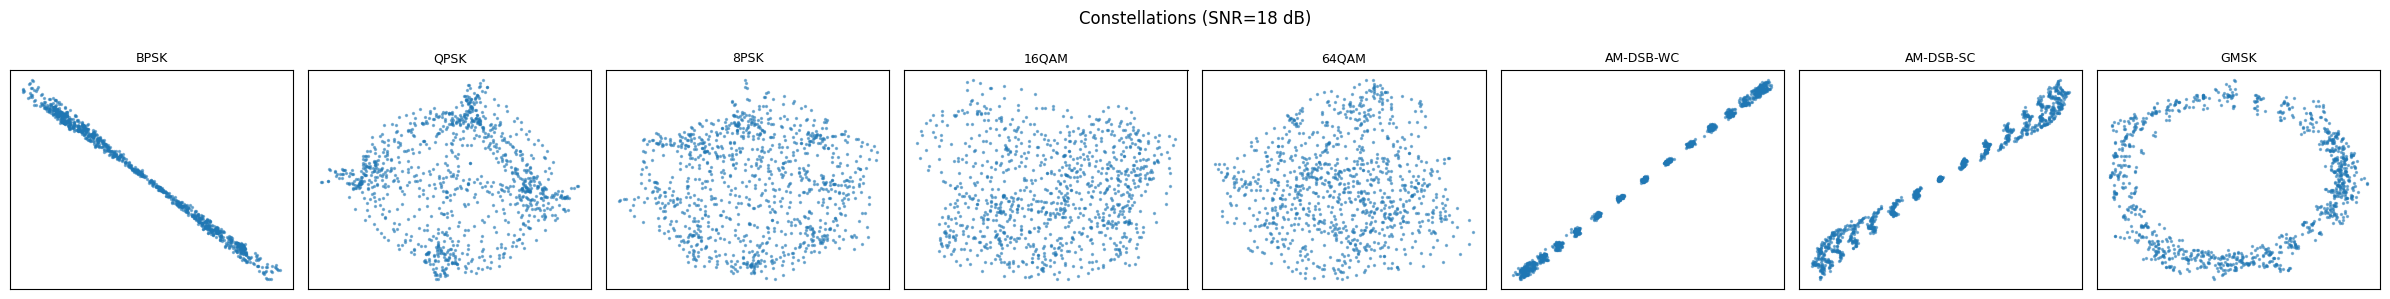


Exported .npz size: 260.13 MB


In [18]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt

REDUCED_PATH = "DEEPSIG_2018_reduced.hdf5"  # adjust path if needed (e.g. /kaggle/working/...)

MOD_LIST_FULL = [  # must match the encoding used when the reduced file was built
    "OOK", "4ASK", "8ASK", "BPSK", "QPSK", "8PSK", "16PSK", "32PSK",
    "16APSK", "32APSK", "64APSK", "128APSK", "16QAM", "32QAM", "64QAM",
    "128QAM", "256QAM", "AM-SSB-WC", "AM-SSB-SC", "AM-DSB-WC", "AM-DSB-SC",
    "FM", "GMSK", "OQPSK",
]

# --- 1. File size on disk -----------------------------------------------
size_bytes = os.path.getsize(REDUCED_PATH)
size_mb = size_bytes / (1024 ** 2)
size_gb = size_bytes / (1024 ** 3)
print(f"File size: {size_bytes:,} bytes  ({size_mb:.2f} MB / {size_gb:.3f} GB)")
print()

# --- 2. Load and inspect --------------------------------------------------
with h5py.File(REDUCED_PATH, "r") as f:
    X = f["X"][:]   # (N, 1024, 2) float32
    Y = f["Y"][:]   # (N, n_classes) one-hot
    Z = f["Z"][:]   # (N, 1) int64, SNR in dB

print("X shape:", X.shape, X.dtype)
print("Y shape:", Y.shape, Y.dtype)
print("Z shape:", Z.shape, Z.dtype)

mod_indices_present = np.unique(np.argmax(Y, axis=1))
mods_present = [MOD_LIST_FULL[i] for i in mod_indices_present]
snrs_present = np.unique(Z)
print("Modulations present:", mods_present)
print("SNRs present (dB):", snrs_present.tolist())
print("Total samples:", X.shape[0])

print()
# --- 3. Visualize ----------------------------------------------------------
rng = np.random.default_rng(0)

# 3a. Class/SNR distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mod_labels = np.argmax(Y, axis=1)
counts_mod = [np.sum(mod_labels == i) for i in mod_indices_present]
axes[0].bar(mods_present, counts_mod)
axes[0].set_title("Samples per modulation")
axes[0].tick_params(axis="x", rotation=45)

counts_snr = [np.sum(Z[:, 0] == s) for s in snrs_present]
axes[1].bar(snrs_present.astype(str), counts_snr)
axes[1].set_title("Samples per SNR (dB)")
plt.tight_layout()
plt.show()

print()

# 3b. Example I/Q waveforms — one per modulation at the highest available SNR
best_snr = snrs_present.max()
fig, axes = plt.subplots(len(mods_present), 1, figsize=(10, 2 * len(mods_present)), sharex=True)
for ax, mod_idx, mod_name in zip(axes, mod_indices_present, mods_present):
    mask = (mod_labels == mod_idx) & (Z[:, 0] == best_snr)
    idx = np.nonzero(mask)[0]
    if len(idx) == 0:
        continue
    i = rng.choice(idx)
    iq = X[i, :200, 0] + 1j * X[i, :200, 1]  # first 200 samples for readability
    ax.plot(iq.real, label="I")
    ax.plot(iq.imag, label="Q")
    ax.set_ylabel(mod_name, rotation=0, labelpad=40, fontsize=9)
axes[0].legend(loc="upper right")
axes[-1].set_xlabel("Sample index")
fig.suptitle(f"Example I/Q waveforms per modulation (SNR={best_snr} dB)")
plt.tight_layout()
plt.show()

print()

# 3c. Constellation diagrams (I vs Q scatter) for the same examples
fig, axes = plt.subplots(1, len(mods_present), figsize=(3 * len(mods_present), 3))
for ax, mod_idx, mod_name in zip(axes, mod_indices_present, mods_present):
    mask = (mod_labels == mod_idx) & (Z[:, 0] == best_snr)
    idx = np.nonzero(mask)[0]
    if len(idx) == 0:
        continue
    i = rng.choice(idx)
    ax.scatter(X[i, :, 0], X[i, :, 1], s=2, alpha=0.5)
    ax.set_title(mod_name, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Constellations (SNR={best_snr} dB)")
plt.tight_layout()
plt.show()

print()

# --- 4. Export ---------------------------------------------------------
# 4a. Save the visualizations
os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/constellations.png", dpi=150)

# 4b. Export the dataset itself as a compressed .npz for easy downstream loading
np.savez_compressed(
    "outputs/DEEPSIG_2018_reduced.npz",
    X=X, Y=Y, Z=Z, mod_list=np.array(MOD_LIST_FULL),
)
exported_size = os.path.getsize("outputs/DEEPSIG_2018_reduced.npz")
print(f"Exported .npz size: {exported_size / (1024**2):.2f} MB")